# Batch Run Comparison

Compare results across all three scenario experiments:

- **Baseline** (`batch_baseline_20260528_231106`)
- **Conservative** (`batch_conservative_20260529_000355`)
- **Optimistic** (`batch_optimistic_20260529_005521`)

Figures produced:

1. Distribution of cumulative profit — three experiments in one figure.
2. BET fleet share — one subplot per experiment.
3. BET fleet share — all three experiments combined with side-by-side boxes.


## 1 — Import libraries


In [ ]:
import pathlib

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fleet_replacement.episode import EpisodeRecord

REPO_ROOT = pathlib.Path.cwd().parent

sns.set_theme(style="whitegrid")

# PGF / LaTeX font settings (mirrors analyse_batch.ipynb)
matplotlib.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "pgf.rcfonts": False,
        "font.family": "serif",
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    }
)

FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures dir: {FIGURES_DIR}")

Figures dir: c:\git\KTH\fleet-replacement\figures


## 2 — Load batch run data

Load all `episode_*.pkl` files from each of the three result folders.


In [ ]:
IMPORTANT_DIR = REPO_ROOT / "results" / "important"

EXPERIMENTS = {
    "Baseline": IMPORTANT_DIR / "batch_baseline_20260528_231106",
    "Conservative": IMPORTANT_DIR / "batch_conservative_20260529_000355",
    "Optimistic": IMPORTANT_DIR / "batch_optimistic_20260529_005521",
}

# Palette — one colour per experiment (used consistently in all figures)
PALETTE = {
    "Baseline": "steelblue",
    "Conservative": "darkorange",
    "Optimistic": "seagreen",
}

# Load all episodes for every experiment
all_records: dict[str, list[EpisodeRecord]] = {}
for name, folder in EXPERIMENTS.items():
    files = sorted(folder.glob("episode_*.pkl"))
    records = [EpisodeRecord.load(str(f)) for f in files]
    all_records[name] = records
    print(
        f"{name:15s}: {len(records)} episodes  "
        f"(years {records[0].years[0]}–{records[0].years[-1]})"
    )

Baseline       : 200 episodes  (years 2026–2045)
Conservative   : 200 episodes  (years 2026–2045)
Optimistic     : 200 episodes  (years 2026–2045)


## 3 — Cumulative profit distribution (all experiments in one figure)


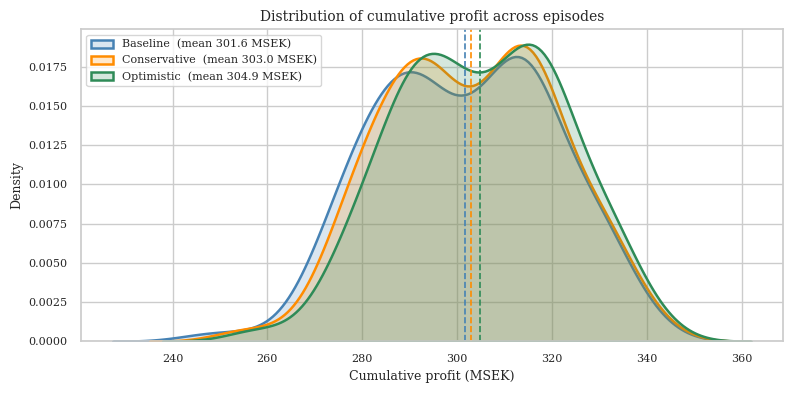

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

for name, records in all_records.items():
    profits = np.array([r.total_reward for r in records]) / 1e6  # MSEK
    sns.kdeplot(
        profits,
        ax=ax,
        label=f"{name}  (mean {profits.mean():.1f} MSEK)",
        color=PALETTE[name],
        linewidth=1.8,
        fill=True,
        alpha=0.20,
    )
    ax.axvline(
        profits.mean(),
        color=PALETTE[name],
        linewidth=1.2,
        linestyle="--",
    )

ax.set_xlabel("Cumulative profit (MSEK)")
ax.set_ylabel("Density")
ax.set_title("Distribution of cumulative profit across episodes")
ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "compare_fig1_cumulative_profit.pgf", backend="pgf")
plt.show()

## 4 — BET fleet share — one subplot per experiment

Each subplot mirrors the style in `analyse_batch.ipynb`.


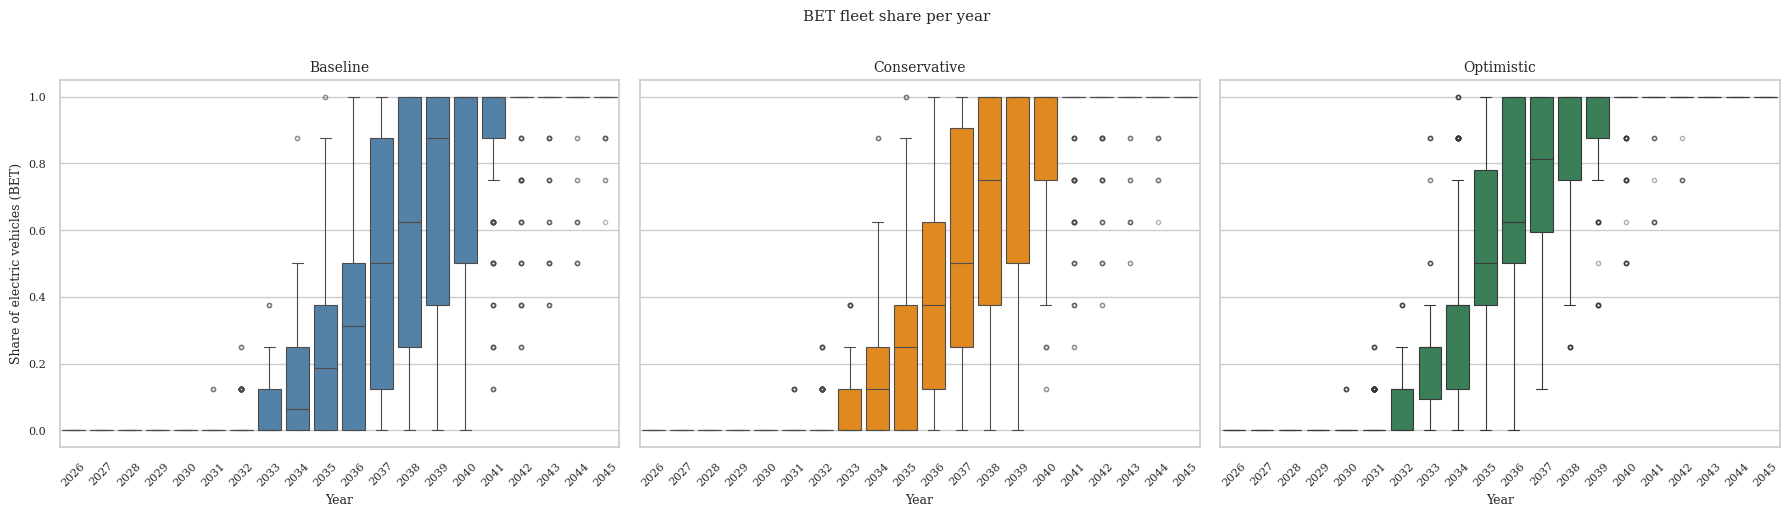

In [ ]:
n_experiments = len(EXPERIMENTS)
fig, axes = plt.subplots(1, n_experiments, figsize=(6 * n_experiments, 5), sharey=True)

for ax, (name, records) in zip(axes, all_records.items()):
    fleet_size = records[0].fleet_size
    years = records[0].years

    df = pd.DataFrame(
        [
            {"year": year, "BET share": n_elec / fleet_size}
            for r in records
            for year, n_elec in zip(r.years, r.n_electric)
        ]
    )

    sns.boxplot(
        data=df,
        x="year",
        y="BET share",
        ax=ax,
        color=PALETTE[name],
        linewidth=0.8,
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    )

    ax.set_ylim(-0.05, 1.05)
    ax.set_title(name)
    ax.set_xlabel("Year")
    ax.set_ylabel("Share of electric vehicles (BET)" if ax is axes[0] else "")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("BET fleet share per year", y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "compare_fig2a_bet_share_subplots.pgf", backend="pgf")
plt.show()

## 5 — BET fleet share — combined figure

Three side-by-side boxes at each timestep, one colour per experiment.


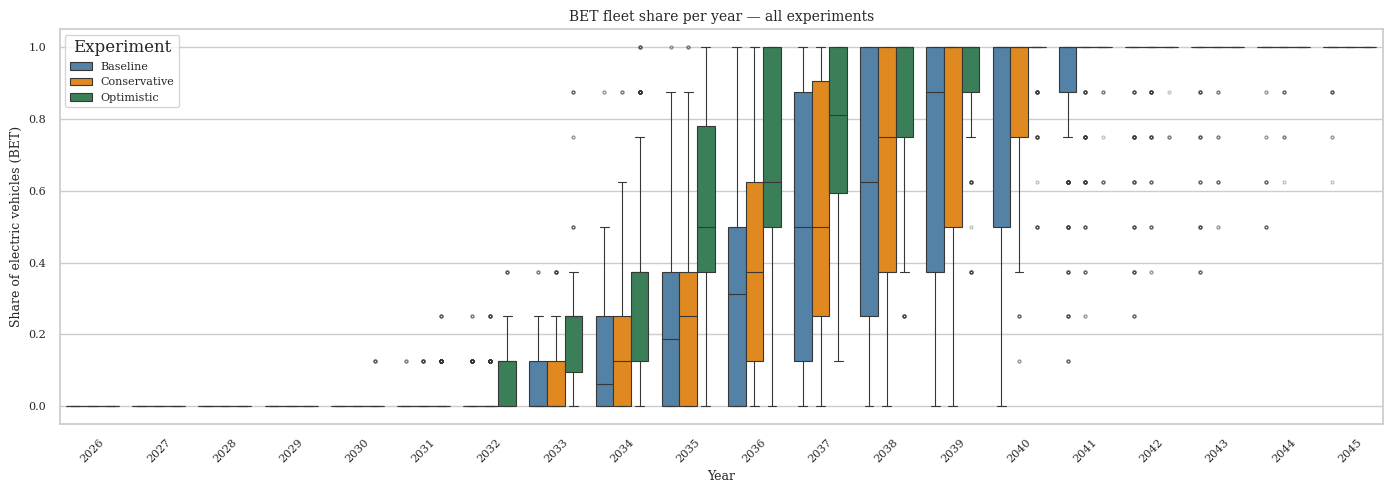

In [6]:
# Build a combined long-form DataFrame with an "Experiment" column
frames = []
for name, records in all_records.items():
    fleet_size = records[0].fleet_size
    df = pd.DataFrame(
        [
            {"year": year, "BET share": n_elec / fleet_size, "Experiment": name}
            for r in records
            for year, n_elec in zip(r.years, r.n_electric)
        ]
    )
    frames.append(df)

combined = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 5))

sns.boxplot(
    data=combined,
    x="year",
    y="BET share",
    hue="Experiment",
    ax=ax,
    palette=PALETTE,
    linewidth=0.8,
    flierprops={"marker": "o", "markersize": 2, "alpha": 0.3},
)

ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Year")
ax.set_ylabel("Share of electric vehicles (BET)")
ax.set_title("BET fleet share per year — all experiments")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Experiment", loc="upper left")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "compare_fig2b_bet_share_combined.pgf", backend="pgf")
plt.show()

## 6 — Exogenous process trajectories (sanity check)

Overlay the median trajectory and 10–90 % band for each experiment.  
If the scenarios were drawn from the same distributions the bands should be statistically indistinguishable.


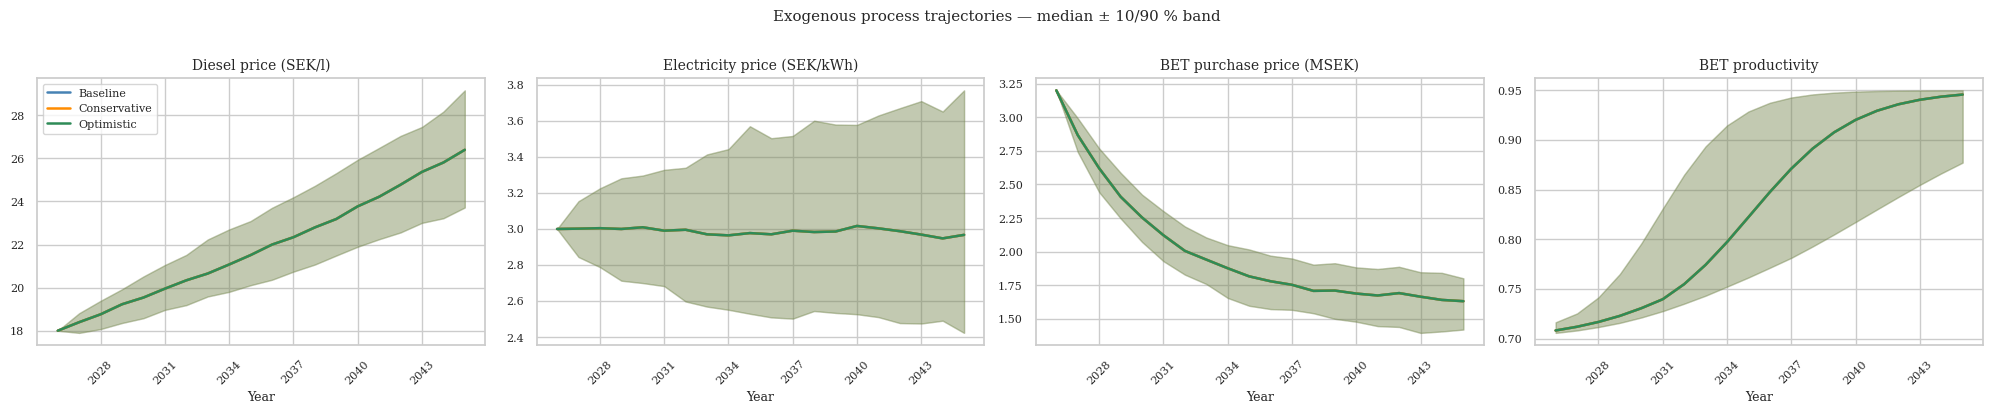

In [ ]:
from matplotlib.ticker import MaxNLocator

_VARIABLES = [
    ("Diesel price (SEK/l)", lambda r: r.energy_prices_diesel),
    ("Electricity price (SEK/kWh)", lambda r: r.energy_prices_electricity),
    ("BET purchase price (MSEK)", lambda r: r.purchase_prices_BET / 1e6),
    ("BET productivity", lambda r: r.productivities_BET),
]

n_cols = len(_VARIABLES)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharey=False)

for ax, (var_label, accessor) in zip(axes, _VARIABLES):
    for name, records in all_records.items():
        years = records[0].years
        mat = np.stack([accessor(r) for r in records])  # (n_episodes, n_steps)
        p10 = np.percentile(mat, 10, axis=0)
        p50 = np.percentile(mat, 50, axis=0)
        p90 = np.percentile(mat, 90, axis=0)

        color = PALETTE[name]
        ax.fill_between(years, p10, p90, color=color, alpha=0.18)
        ax.plot(years, p50, color=color, linewidth=1.8, label=name)

    ax.set_title(var_label)
    ax.set_xlabel("Year")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="x", rotation=45)

axes[0].legend(fontsize=8)
fig.suptitle("Exogenous process trajectories — median ± 10/90 % band", y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "compare_fig3_info_state.pgf", backend="pgf")
plt.show()